In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import scanpy as sc
import ccAFv2 as cc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

E0000 00:00:1779360107.224554 2767700 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779360107.251235 2767700 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata = sc.read_h5ad(data_dir + "adata_tumour.h5ad")

In [7]:
predicted_labels = cc.predict_labels(adata, species="human", gene_id="symbol")

Running ccAFv2:
    Preparing data for classification...
    Marker genes present in this dataset: 854
    Missing marker genes in this dataset: 7
  Predicting cell cycle state probabilities...
2680/2680 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
  Choosing cell cycle state...
Done.


In [8]:
# Save into scanpy object
adata.obs["ccaf_categories"] = pd.Categorical(
    predicted_labels[0],
    categories=["", "G1", "Late G1", "S", "S/G2", "G2/M", "M/Early G1", "Unknown", "qG0"],
    ordered=True,
)

In [ ]:
cmap = LinearSegmentedColormap.from_list("quiescence", ["#2FBF71", "#8C8C8C", "#6A5ACD"], N=256)

adata.uns["ccaf_categories_colors"] = [
    "#DDDDDD",
    "#4E79A7",
    "#59A14F",
    "#E15759",
    "#B07AA1",
    "#9C755F",
    "#EDC948",
    "#808080",
    "#D8BFD8", # light purple for qG0
]

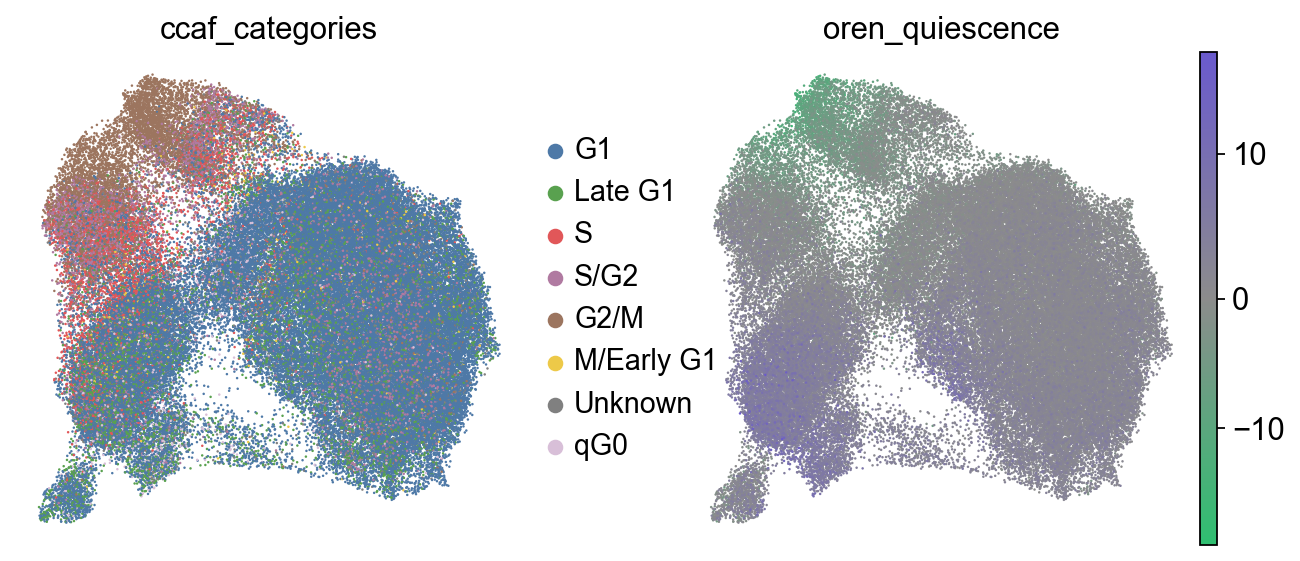

In [11]:
sc.pl.umap(
    adata,
    color=["ccaf_categories", "oren_quiescence"],
    size=5,
    cmap=cmap,
    vcenter=0,
    save="_ccafv2_vs_oren.pdf",
)

ccaf_categories        G1  Late G1     S  S/G2  G2/M  M/Early G1  Unknown  qG0
cycling_state_oren                                                            
Fast-cycling        11278     1475  1377  1824  5795         186      848  404
G0-arrested          3875     1013   383   205    41          30      305  286
Slow-cycling        40328     6555  2191  2515  1412         336     2362  725


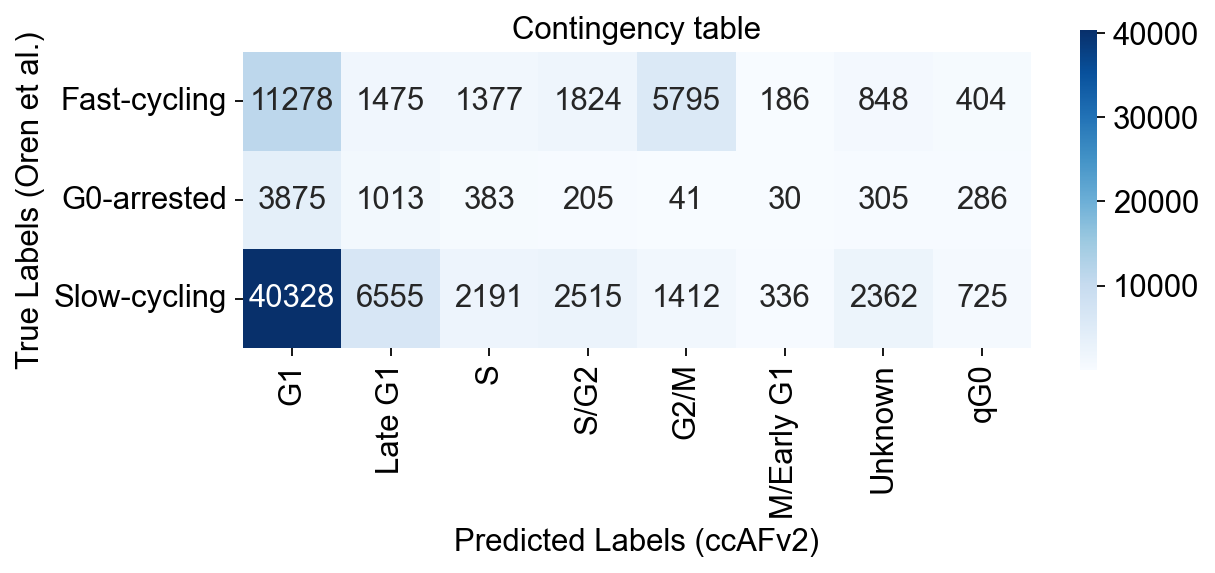

In [12]:
# correlate the results with our previous annotations
contingency_table = pd.crosstab(adata.obs["cycling_state_oren"], adata.obs["ccaf_categories"])
print(contingency_table)

# plot heatmap of the contingency table
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", square=True, cbar_kws={"shrink": 0.38})
plt.xlabel("Predicted Labels (ccAFv2)")
plt.ylabel("True Labels (Oren et al.)")
plt.title("Contingency table")
plt.tight_layout()
plt.grid(False)
plt.savefig(figure_dir + "ccafv2_contingency_table_heatmap.pdf")
plt.show()

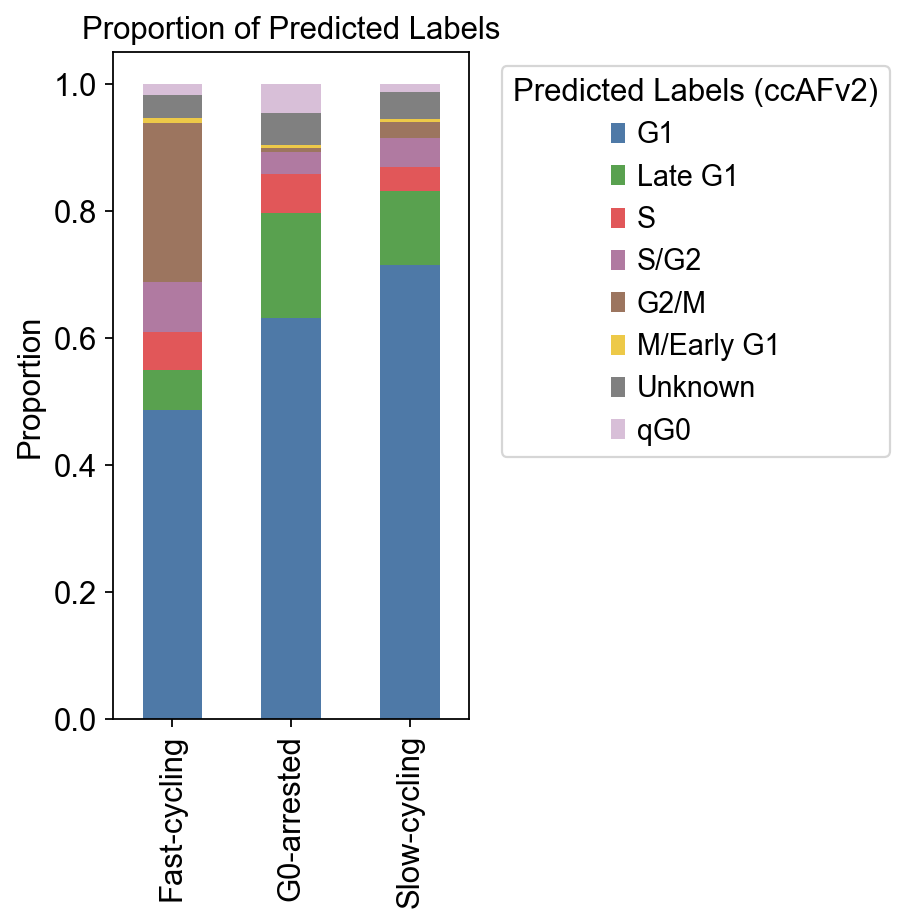

In [13]:
# Bar plot of the proportions
from matplotlib.colors import ListedColormap
palette = ListedColormap([
    "#4E79A7",
    "#59A14F",
    "#E15759",
    "#B07AA1",
    "#9C755F",
    "#EDC948",
    "#808080",
    "#D8BFD8",
])

proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0)
proportions.plot(kind="bar", stacked=True, figsize=(6, 6), colormap=palette)
plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Proportion of Predicted Labels")
plt.legend(title="Predicted Labels (ccAFv2)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(False)
plt.savefig(figure_dir + "ccafv2_proportions_barplot.pdf")
plt.show()